<a href="https://colab.research.google.com/github/AmineAis/Machine-Learning-Project/blob/main/AIProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

DATASET
      Date Symbol Series  Prev Close   Open   High    Low    Last   Close  \
0  6/23/04     LT     EQ        2.00  500.0  745.0  150.0  638.00  635.95   
1  6/24/04     LT     EQ      635.95  630.0  630.0  608.4  612.00  616.00   
2  6/25/04     LT     EQ      616.00  619.0  679.0  616.1  665.00  668.30   
3  6/28/04     LT     EQ      668.30  660.0  671.9  640.2  653.00  656.40   
4  6/29/04     LT     EQ      656.40  656.0  683.4  653.0  666.85  671.70   

     VWAP   Volume      Turnover  Trades  Deliverable Volume  %Deliverble  
0  627.71  2699293  1.694370e+14     NaN              395612       0.1466  
1  618.21   913575  5.647800e+13     NaN              305751       0.3347  
2  658.45  1637383  1.078140e+14     NaN              217950       0.1331  
3  657.39   913349  6.004270e+13     NaN              194984       0.2135  
4  675.11   743063  5.016490e+13     NaN              101786       0.1370  

Missing Values:
 Date                  0
Symb

<Figure size 600x600 with 0 Axes>

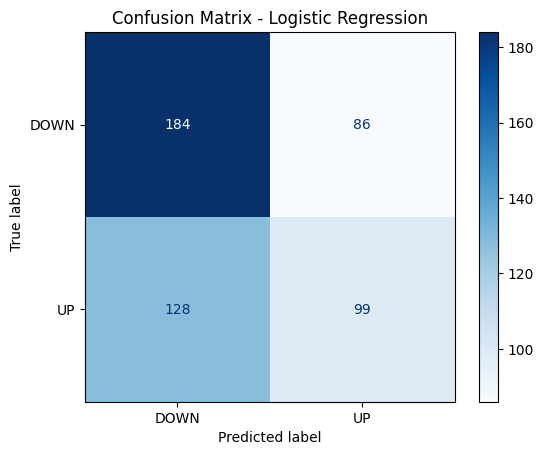

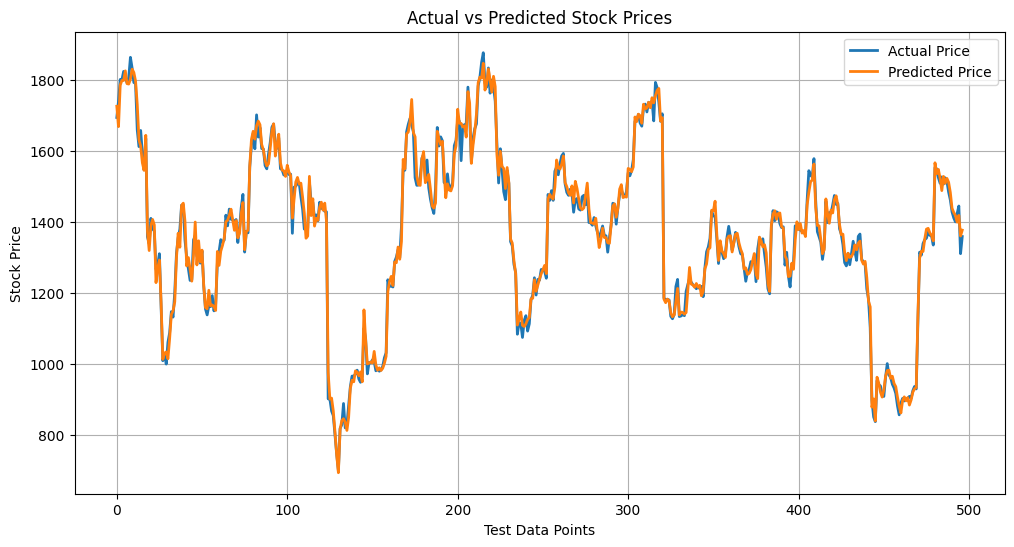

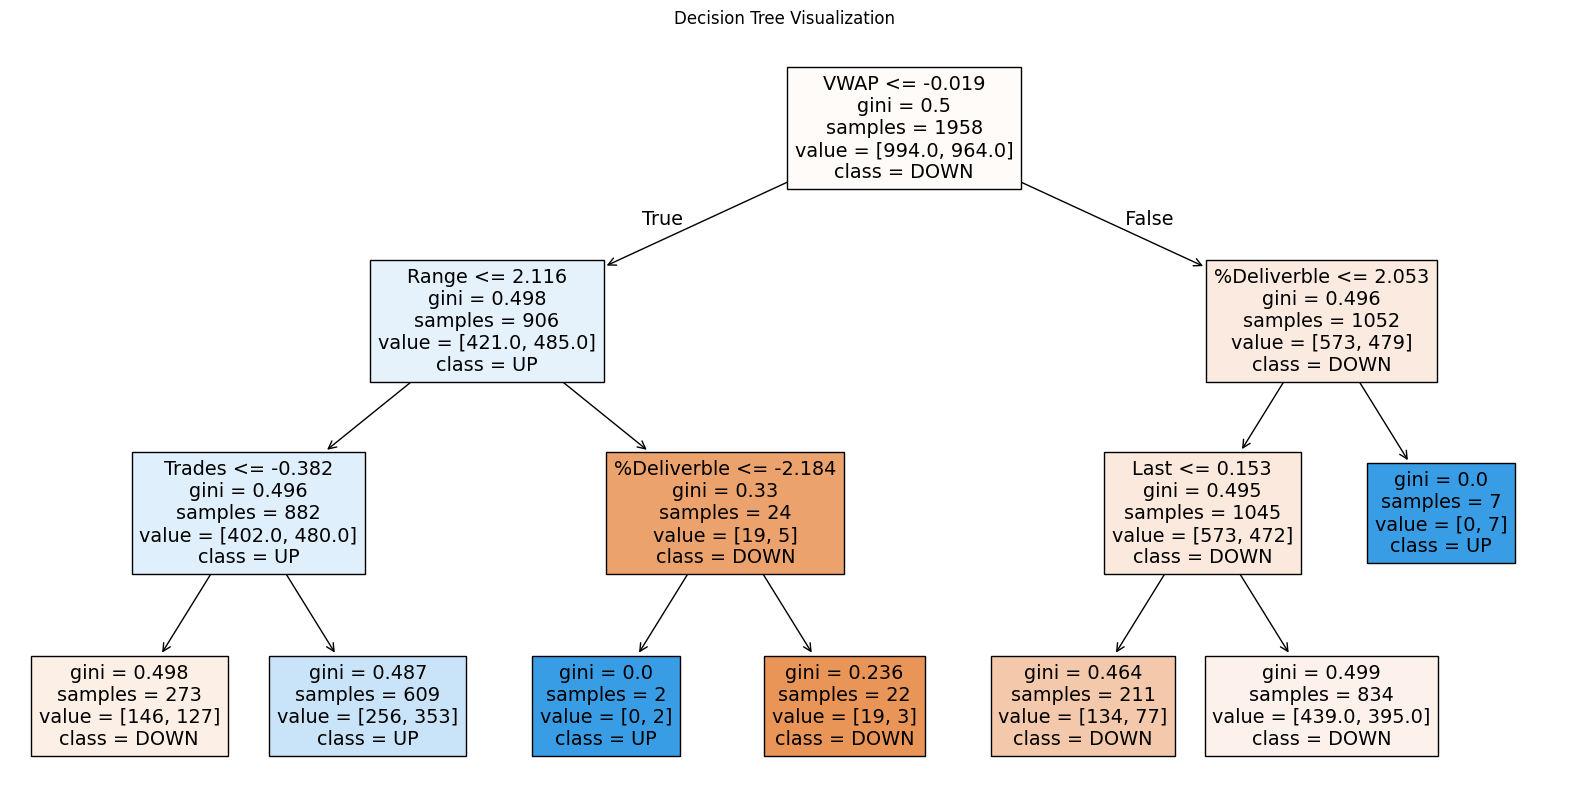

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.tree import DecisionTreeClassifier, plot_tree


df = pd.read_csv("/content/stock_data.csv")

print("\nDATASET")
print(df.head())


df = df.dropna()

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df = df.sort_values('Date')

print("\nMissing Values:\n", df.isnull().sum())

print("\nOutlier Check:")
print("Close Max:", df['Close'].max())
print("Close Min:", df['Close'].min())

print("\nFeature Correlation with Close:")
print(df.corr(numeric_only=True)['Close'].sort_values(ascending=False))


df['Daily_Return'] = (df['Close'] - df['Prev Close']) / df['Prev Close']
df['Range'] = df['High'] - df['Low']

df['Target_Class'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df['Target_Price'] = df['Close'].shift(-1)

df = df.dropna()
df = pd.get_dummies(df, columns=['Symbol', 'Series'], drop_first=True)


X = df.drop(['Target_Class', 'Target_Price', 'Date'], axis=1)
y_class = df['Target_Class']
y_price = df['Target_Price']

np.random.seed(42)


for run in range(1, 11):

    msk = np.random.rand(len(X)) < 0.8

    X_train, X_test = X[msk], X[~msk]
    y_train_c, y_test_c = y_class[msk], y_class[~msk]
    y_train_p, y_test_p = y_price[msk], y_price[~msk]


    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train_c)

    log_pred = log_model.predict(X_test)

    acc = accuracy_score(y_test_c, log_pred)
    prec = precision_score(y_test_c, log_pred, zero_division=0)
    rec = recall_score(y_test_c, log_pred)
    f1 = f1_score(y_test_c, log_pred)

    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train_p)

    lin_pred = lin_model.predict(X_test)

    mse = mean_squared_error(y_test_p, lin_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_p, lin_pred)
    r2 = r2_score(y_test_p, lin_pred)


    tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree_model.fit(X_train, y_train_c)

    tree_pred = tree_model.predict(X_test)

    print(f"\nTest {run}")
    print(f"Logistic → Acc:{acc:.4f}, Prec:{prec:.4f}, Rec:{rec:.4f}, F1:{f1:.4f}")
    print(f"Linear   → R2:{r2:.4f}, MAE:{mae:.4f}, RMSE:{rmse:.4f}")



cm = confusion_matrix(y_test_c, log_pred)

plt.figure(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



plt.figure(figsize=(12, 6))

plt.plot(
    y_test_p.values,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    lin_pred,
    label="Predicted Price",
    linewidth=2
)

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Test Data Points")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()



plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["DOWN", "UP"],
    filled=True
)

plt.title("Decision Tree Visualization")

plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
